#Bidirectional RNN

Limitation Of Simple RNN

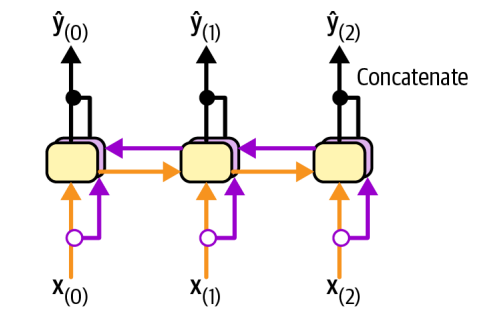

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN,Bidirectional, Dense,LSTM,GRU

In [ ]:
# Load the IMDb dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences to have the same length
x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Build Uniirectional RNN model
model = Sequential([
    Embedding(10000, 16, input_length=100),
    SimpleRNN(16),  # <-- Unidirectional RNN
    Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6960 - loss: 0.5721 - val_accuracy: 0.8130 - val_loss: 0.4224
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8761 - loss: 0.3211 - val_accuracy: 0.8304 - val_loss: 0.3939
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9160 - loss: 0.2326 - val_accuracy: 0.8302 - val_loss: 0.4086
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9472 - loss: 0.1597 - val_accuracy: 0.8184 - val_loss: 0.4134
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9655 - loss: 0.1161 - val_accuracy: 0.8370 - val_loss: 0.4597
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9727 - loss: 0.0899 - val_accuracy: 0.8280 - val_loss: 0.4919
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9831 - loss: 0.0647 - val_accuracy: 0.8110 - val_loss: 0.5313
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9884 - loss: 0.0447 - val_accuracy:

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481,637 (1.84 MB)

 Trainable params: 160,545 (627.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 321,092 (1.22 MB)

In [ ]:
# Build Bidirectional RNN model
model = Sequential([
    Embedding(10000, 16, input_length=100),
    Bidirectional(SimpleRNN(16)),  # <-- Bidirectional RNN
    Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.6484 - loss: 0.6170 - val_accuracy: 0.8132 - val_loss: 0.4258
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8687 - loss: 0.3347 - val_accuracy: 0.8396 - val_loss: 0.3694
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9225 - loss: 0.2130 - val_accuracy: 0.8322 - val_loss: 0.3973
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9442 - loss: 0.1556 - val_accuracy: 0.8286 - val_loss: 0.4153
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9689 - loss: 0.0980 - val_accuracy: 0.8270 - val_loss: 0.4829
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9864 - loss: 0.0494 - val_accuracy: 0.8296 - val_loss: 0.5494
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9933 - loss: 0.0296 - val_accuracy: 0.8256 - val_loss: 0.6980
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9941 - loss: 0.0230 - val_ac

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 483,269 (1.84 MB)

 Trainable params: 161,089 (629.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 322,180 (1.23 MB)